# Shape toroidal AutoEncoder
latent space $\mathbb{R}^D / {A\mathbb{Z}^D$ with $A$ learnable

In [248]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [249]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [250]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
from lib.trainer import AETrainer
import lib.utils as utils



### Set up and initialize data loader

In [251]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [252]:
A = torch.tensor([[.1, 0.0], [0.0, 10.0]])  # Example A
embed_dim = 10

batch_size = 64

_, pointcloud, pointcloud_embedded = dataloaders.generate_toroidal_pointcloud(A=A, embed_dim=embed_dim, num_points=10000)
dataloader = dataloaders.load_shaped_torus(pointcloud_embedded,batch_size)

### Model

In [253]:
data_dim = embed_dim
hidden_dim1 = 6
hidden_dim2 = 4
latent_dim = 2

shape_model = models.ShapeToroidalAE(data_dim=data_dim, hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, latent_dim=latent_dim)
euclidean_model = models.EuclideanAE(data_dim=data_dim, hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, latent_dim=2*latent_dim)

### Optimizer

In [254]:
learning_rate = 0.001

shape_optimizer = optim.Adam(shape_model.parameters(), lr=learning_rate)
euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)

### Trainer setup

In [255]:
num_epochs = 50
log_interval = 100
device = "cpu"
dataset = "synthetic"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device, 'dataset': dataset }

train_loader, test_loader = dataloader


### Train and evaluate shape model

In [256]:
ae_history = AETrainer(shape_model, dataloader, shape_optimizer, trainer_config).train()

Trainer successfully initialized.
Start training...
Epoch 0
Step [100/141], Loss: 9.0257, Shape matrix A:1, A_inv_T:1
Epoch 1/50, Train Loss: 9.3784, Test Loss: 8.1272
Epoch 1
Step [100/141], Loss: 4.9223, Shape matrix A:1, A_inv_T:1
Epoch 2/50, Train Loss: 5.9041, Test Loss: 3.4274
Epoch 2
Step [100/141], Loss: 1.0436, Shape matrix A:1, A_inv_T:1
Epoch 3/50, Train Loss: 1.6506, Test Loss: 0.5289
Epoch 3
Step [100/141], Loss: 0.3104, Shape matrix A:1, A_inv_T:1
Epoch 4/50, Train Loss: 0.3649, Test Loss: 0.3189
Epoch 4
Step [100/141], Loss: 0.3268, Shape matrix A:1, A_inv_T:1
Epoch 5/50, Train Loss: 0.3185, Test Loss: 0.3128
Epoch 5
Step [100/141], Loss: 0.3616, Shape matrix A:1, A_inv_T:1
Epoch 6/50, Train Loss: 0.3153, Test Loss: 0.3109
Epoch 6
Step [100/141], Loss: 0.3192, Shape matrix A:1, A_inv_T:1
Epoch 7/50, Train Loss: 0.3130, Test Loss: 0.3086
Epoch 7
Step [100/141], Loss: 0.3362, Shape matrix A:1, A_inv_T:1
Epoch 8/50, Train Loss: 0.3111, Test Loss: 0.3060
Epoch 8
Step [100/14

latent_vars tensor([[-0.9358,  0.7498,  0.3524,  0.6616],
        [-0.9421,  0.1853, -0.3352,  0.9827],
        [-1.0000,  0.4795, -0.0089,  0.8776],
        ...,
        [-0.9616,  0.6964,  0.2743,  0.7177],
        [-0.9751,  0.6589,  0.2219,  0.7522],
        [-0.9862,  0.3446, -0.1656,  0.9388]]) torch.Size([9000, 4])


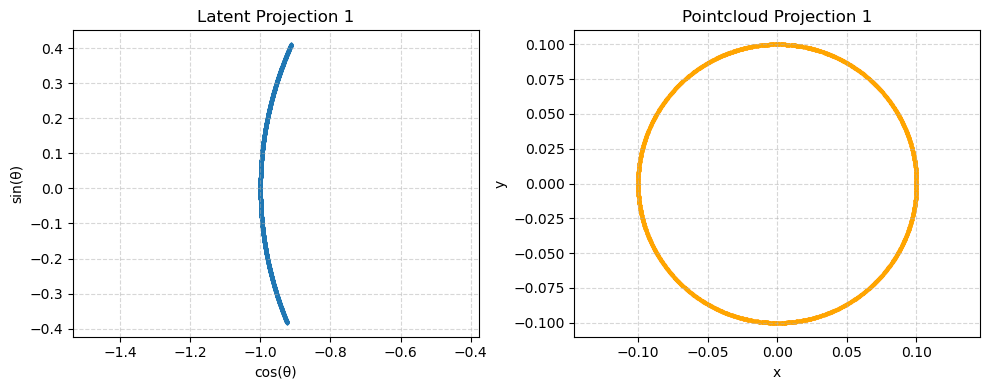

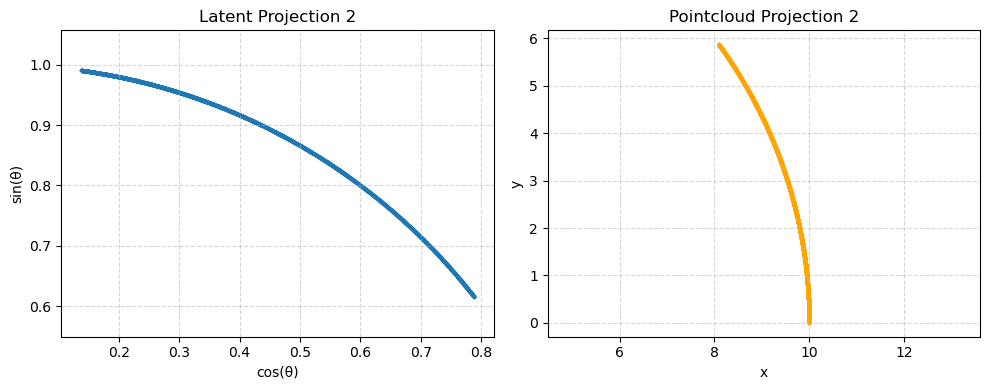

In [257]:
utils.plot_latent_projections(shape_model, pointcloud, train_loader)

### Train and evaluate euclidean model

In [258]:
euclid_ae_history = AETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()

Trainer successfully initialized.
Start training...
Epoch 0
Step [100/141], Loss: 9.4561, Shape matrix A:not defined, A_inv_T:not defined
Epoch 1/50, Train Loss: 9.6239, Test Loss: 8.9360
Epoch 1
Step [100/141], Loss: 0.9163, Shape matrix A:not defined, A_inv_T:not defined
Epoch 2/50, Train Loss: 3.9576, Test Loss: 0.4075
Epoch 2
Step [100/141], Loss: 0.4500, Shape matrix A:not defined, A_inv_T:not defined
Epoch 3/50, Train Loss: 0.3885, Test Loss: 0.3690
Epoch 3
Step [100/141], Loss: 0.3413, Shape matrix A:not defined, A_inv_T:not defined
Epoch 4/50, Train Loss: 0.3602, Test Loss: 0.3465
Epoch 4
Step [100/141], Loss: 0.3805, Shape matrix A:not defined, A_inv_T:not defined
Epoch 5/50, Train Loss: 0.3432, Test Loss: 0.3346
Epoch 5
Step [100/141], Loss: 0.3163, Shape matrix A:not defined, A_inv_T:not defined
Epoch 6/50, Train Loss: 0.3339, Test Loss: 0.3284
Epoch 6
Step [100/141], Loss: 0.3743, Shape matrix A:not defined, A_inv_T:not defined
Epoch 7/50, Train Loss: 0.3296, Test Loss: 0.3

latent_vars tensor([[ -4.2815,  -0.3054,  -1.3466,  -8.8680],
        [ -4.1160,  -0.1151,  -0.7732,  -9.5410],
        [ -2.9802,   0.9465,   2.4291, -12.7118],
        ...,
        [ -4.7549,  -0.9581,  -3.3136,  -6.2979],
        [ -4.6892,  -0.8536,  -2.9987,  -6.7372],
        [ -3.3953,   0.5987,   1.3797, -11.7918]]) torch.Size([9000, 4])


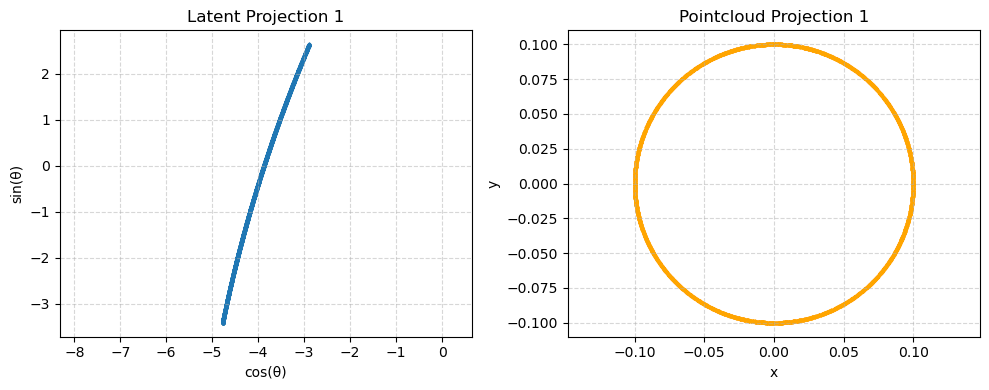

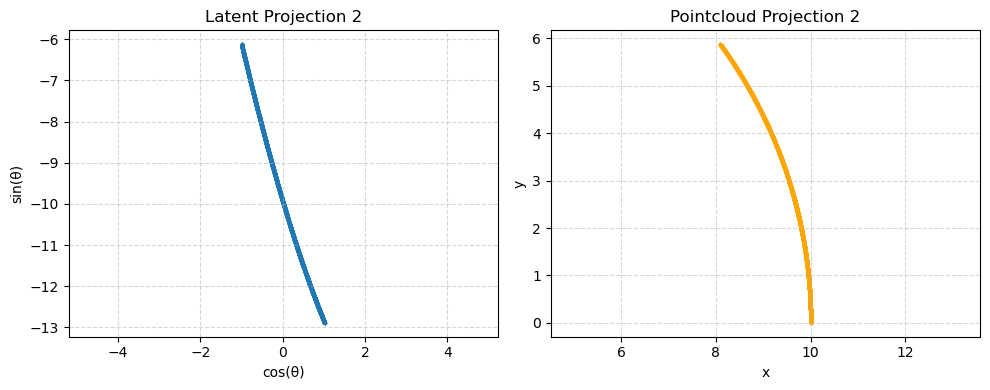

In [259]:
utils.plot_latent_projections(euclidean_model,pointcloud, train_loader)
